# **Eksplorasi Data**
Eksplorasi data bertujuan untuk mendeskripsikan statistik untuk memahami distribusi data

Note: Melanjutkan dari sebelumnya.


#####**a. Menghubungkan Data dari MySQL dan PostgreSQL**
*   Install library yang diperlukan

In [2]:
!pip install pymysql
!pip install pandas
!pip install psycopg2-binary
!pip install sqlalchemy
!pip install python-dotenv

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 45.3/45.3 kB 2.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.0/3.0 MB 35.7 MB/s eta 0:00:00


*   Koneksikan database dari aiven

In [3]:
import pandas as pd
from sqlalchemy import create_engine

# Koneksi ke MySQL
MYSQL_HOST = "mysql-3634ef1a-tugas-pendata.g.aivencloud.com"
MYSQL_PORT = 17416
MYSQL_USER = "avnadmin"
MYSQL_PASSWORD = "AVNS_2NRSFWfr9pGMEI7BSpA"
MYSQL_DATABASE = "defaultdb"

# Koneksi ke PostgreSQL
PG_HOST = "pg-359aec68-tugas-pendata.g.aivencloud.com"
PG_PORT = 17416
PG_USER = "avnadmin"
PG_PASSWORD = "AVNS_oal2yP3mG6JLIwX3BUK"
PG_DATABASE = "defaultdb"

# Gunakan SQLAlchemy untuk koneksi ke MySQL
mysql_engine = create_engine(
    f"mysql+pymysql://{MYSQL_USER}:{MYSQL_PASSWORD}@{MYSQL_HOST}:{MYSQL_PORT}/{MYSQL_DATABASE}"
)

# Gunakan SQLAlchemy untuk koneksi ke PostgreSQL
pg_engine = create_engine(
    f"postgresql+psycopg2://{PG_USER}:{PG_PASSWORD}@{PG_HOST}:{PG_PORT}/{PG_DATABASE}"
)

# Jalankan query
mysql_query = "SELECT * FROM iris_data;"
df_mysql = pd.read_sql(mysql_query, mysql_engine)

pg_query = "SELECT * FROM iris_data;"
df_postgres = pd.read_sql(pg_query, pg_engine)

# Print hasil
print("Data dari MySQL:")
print(df_mysql.head())

print("\nData dari PostgreSQL:")
print(df_postgres.head())


Data dari MySQL:
   id        class  petal_length  petal_width
0   1  Iris-setosa           1.4          0.2
1   2  Iris-setosa           1.4          0.2
2   3  Iris-setosa           1.3          0.2
3   4  Iris-setosa           1.5          0.2
4   5  Iris-setosa           1.4          0.2

Data dari PostgreSQL:
   id        class  sepal_length  sepal_width
0   1  Iris-setosa           5.1          3.5
1   2  Iris-setosa           4.9          3.0
2   3  Iris-setosa           4.7          3.2
3   4  Iris-setosa           4.6          3.1
4   5  Iris-setosa           5.0          3.6


In [4]:
df_combined = pd.merge(df_postgres, df_mysql.drop(columns=['class']), on="id", how="inner")

print("\nData gabungan:")
print(df_combined)


Data gabungan:
      id           class  sepal_length  sepal_width  petal_length  petal_width
0      1     Iris-setosa           5.1          3.5           1.4          0.2
1      2     Iris-setosa           4.9          3.0           1.4          0.2
2      3     Iris-setosa           4.7          3.2           1.3          0.2
3      4     Iris-setosa           4.6          3.1           1.5          0.2
4      5     Iris-setosa           5.0          3.6           1.4          0.2
..   ...             ...           ...          ...           ...          ...
145  146  Iris-virginica           6.7          3.0           5.2          2.3
146  147  Iris-virginica           6.3          2.5           5.0          1.9
147  148  Iris-virginica           6.5          3.0           5.2          2.0
148  149  Iris-virginica           6.2          3.4           5.4          2.3
149  150  Iris-virginica           5.9          3.0           5.1          1.8

[150 rows x 6 columns]


In [5]:
df_combined.drop(columns=['id']).describe().loc[['mean', 'std', 'min', '50%', 'max']]

,sepal_length,sepal_width,petal_length,petal_width
mean,5.843333,3.054000,3.758667,1.198667
std,0.828066,0.433594,1.764420,0.763161
min,4.300000,2.000000,1.000000,0.100000
50%,5.800000,3.000000,4.350000,1.300000
max,7.900000,4.400000,6.900000,2.500000


**a. Distribusi Data Numerik**

menggunakan histogram untuk melihat sebaran nilai dari setiap fitur

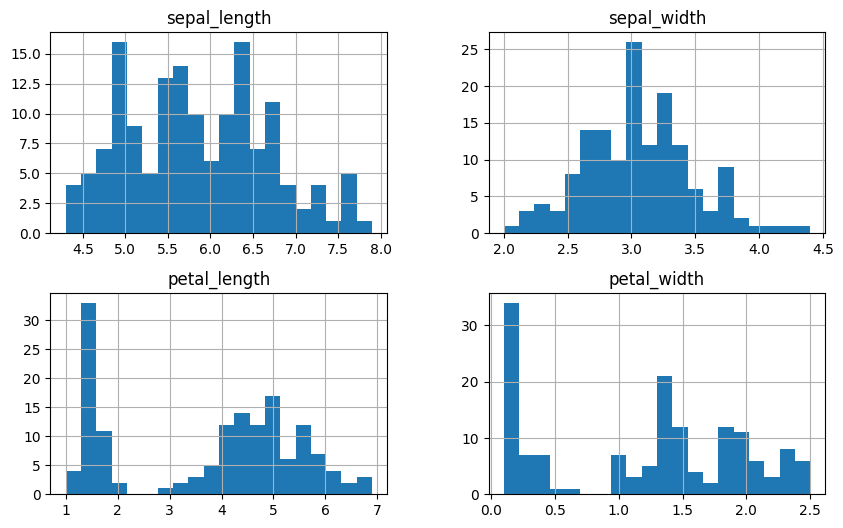

In [6]:
import matplotlib.pyplot as plt

df_combined.loc[:, df_combined.columns != 'id'].hist(figsize=(10, 6), bins=20)
plt.show()

**b. Hubungan antar Variabel**

Scatter plot membantu melihat hubungan antara dua variabel numerik.

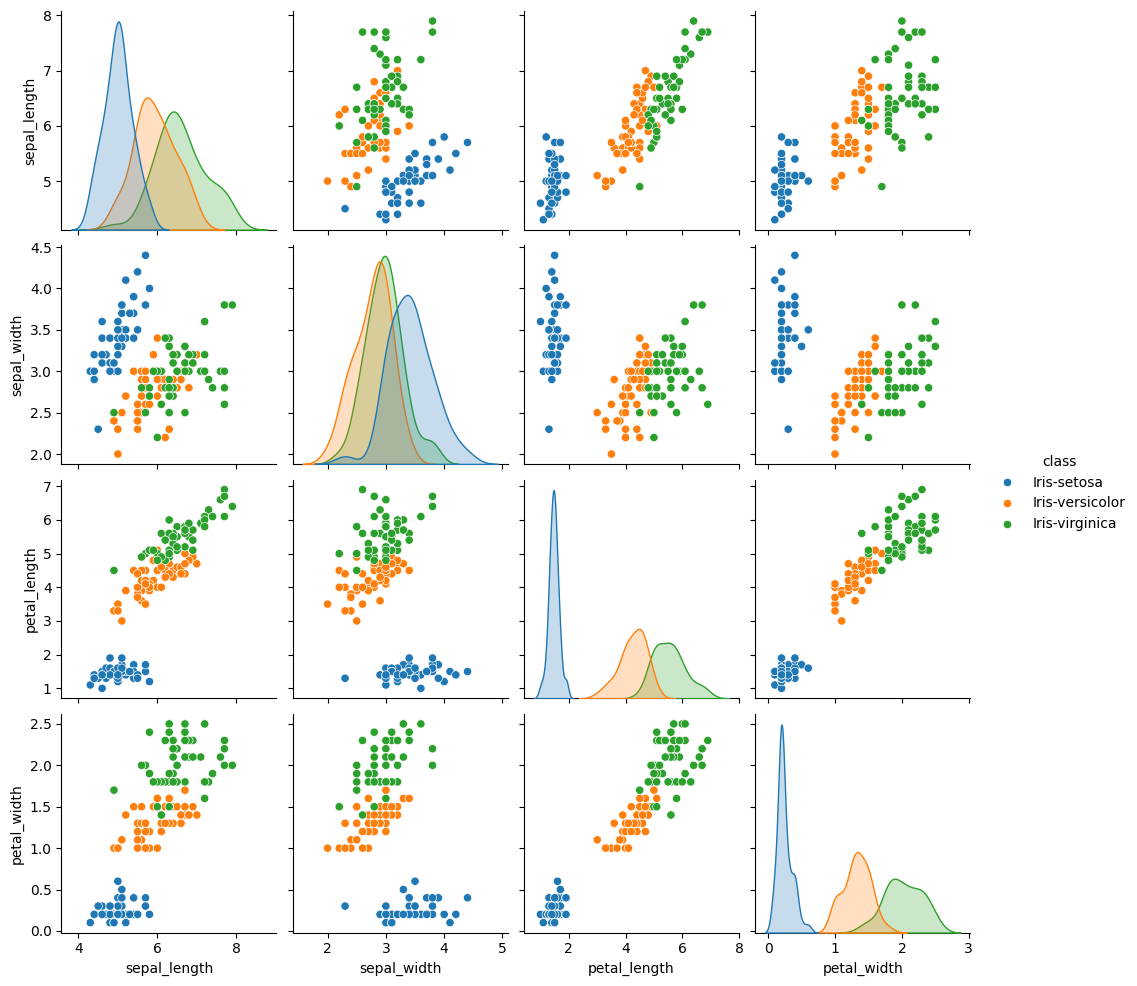

In [7]:
import seaborn as sns

sns.pairplot(df_combined.drop(columns=["id"]), hue="class")
plt.show()

**c. Ditribusi Data tiap Kategori**

Menggunakan box plot untuk melihat tiap kategori.

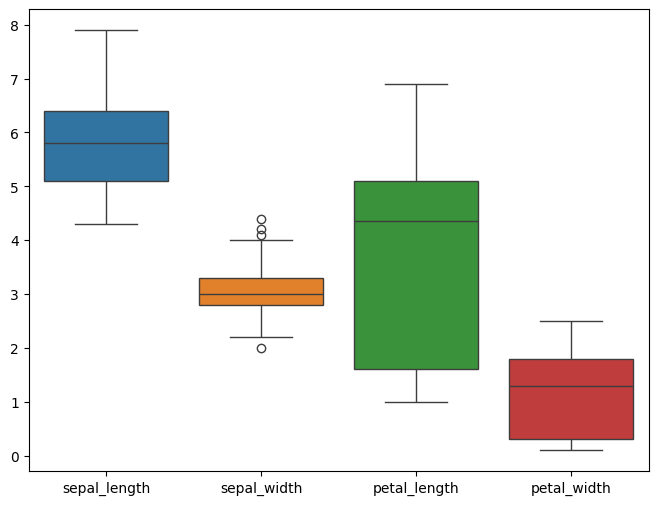

In [8]:
plt.figure(figsize=(8,6))
sns.boxplot(data=df_combined.loc[:, df_combined.columns != 'id'])
plt.show()

**d. Proporsi tiap Spesies Bunga**

Menggunakan pie chart untuk melihat tiap spesies bunga.

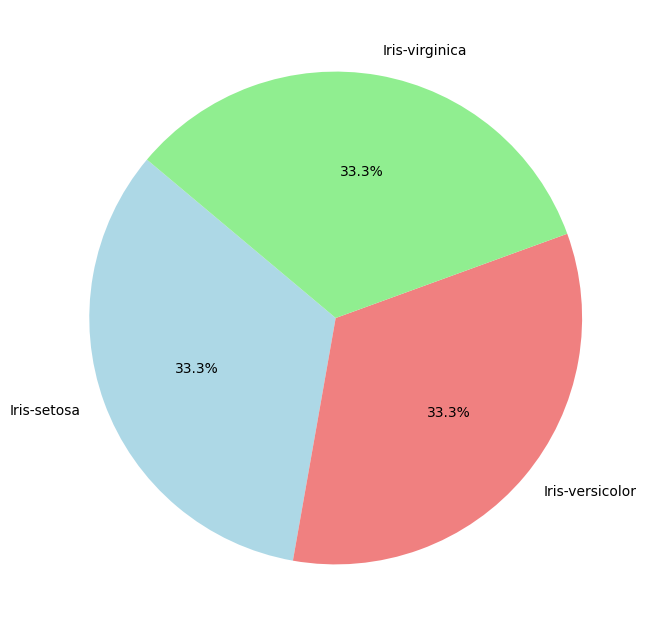

In [9]:
import matplotlib.pyplot as plt

category_counts = df_combined['class'].value_counts()

# Membuat pie chart
plt.figure(figsize=(8, 8))
plt.pie(category_counts, labels=category_counts.index, autopct='%1.1f%%', startangle=140, colors=['lightblue', 'lightcoral', 'lightgreen'])
plt.show()


## **Indentifikasi Masalah**

Mengidentifikasi Masalah jika menemukan potensi kendala dalam dataset yang bisa mempengaruhi analisis dan modeling.

### **Mengecek Data Hilang (Missing Value)**

In [10]:
print(df_combined.isnull().sum())

id              0
class           0
sepal_length    0
sepal_width     0
petal_length    0
petal_width     0
dtype: int64


### **Mendeteksi Outliers**

In [11]:
# Memilih hanya kolom numerik
df_numeric = df_combined.select_dtypes(include=['number'])

# Menghitung IQR
Q1 = df_numeric.quantile(0.25)
Q3 = df_numeric.quantile(0.75)
IQR = Q3 - Q1

# Menentukan outliers
outliers = (df_numeric < (Q1 - 1.5 * IQR)) | (df_numeric > (Q3 + 1.5 * IQR))
print(outliers.sum())


id              0
sepal_length    0
sepal_width     4
petal_length    0
petal_width     0
dtype: int64


### **Mengecek Duplikasi Data**


In [ ]:
print(df_combined.duplicated().sum())

### **Mengecek Inkonsistensi**

In [12]:
# Cek kategori unik dalam Class
print(df_combined['class'].unique())

['Iris-setosa' 'Iris-versicolor' 'Iris-virginica']


In [13]:
# Cek tipe data setiap kolom
print(df_combined.dtypes)

id                int64
class            object
sepal_length    float64
sepal_width     float64
petal_length    float64
petal_width     float64
dtype: object


In [15]:
# cek tipe data setiap nilai
for col in ['sepal_length', 'sepal_width', 'petal_length', 'petal_width']:
    print(f"{col}: {df_combined[col].apply(type).unique()}")

sepal_length: [<class 'float'>]
sepal_width: [<class 'float'>]
petal_length: [<class 'float'>]
petal_width: [<class 'float'>]
